In [26]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

filename = "https://raw.githubusercontent.com/OpenClassrooms-Student-Center/8063076-Initiez-vous-au-Machine-Learning/master/data/palmer_penguins.csv"
data = pd.read_csv(filename)

In [27]:
print(data['sex'].dtype)
print(data['sex'].unique())

str
<StringArray>
['male', 'female', nan]
Length: 3, dtype: str


In [28]:
data['sex'] = data['sex'].map({'male': 0, 'female': 1})
data.dropna(inplace=True)
data['sex'] = data['sex'].astype(int)


In [29]:
data['sex'].value_counts()

sex
0    168
1    165
Name: count, dtype: int64

In [30]:
scaler = MinMaxScaler()
y = data['sex'].values
X = scaler.fit_transform(data[['bill_length_mm','bill_depth_mm','flipper_length_mm', 'body_mass_g']])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

clf = LogisticRegression(random_state = 42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)
confusion_matrix(y_test, y_pred)

array([[28,  3],
       [ 6, 30]])

In [31]:
from sklearn.metrics import confusion_matrix

# Probabilités pour la classe 1 (female)
y_proba = clf.predict_proba(X_test)[:,1]

# Prédictions avec seuils
y_pred_03 = [0 if value < 0.3 else 1 for value in y_proba]
y_pred_07 = [0 if value < 0.7 else 1 for value in y_proba]

# Matrices de confusion
cm_03 = confusion_matrix(y_test, y_pred_03)
cm_07 = confusion_matrix(y_test, y_pred_07)

# Affichage
print("Matrice de confusion (seuil = 0.3)")
print(cm_03)

tn, fp, fn, tp = cm_03.ravel()
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

print("\nMatrice de confusion (seuil = 0.7)")
print(cm_07)

tn, fp, fn, tp = cm_07.ravel()
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

Matrice de confusion (seuil = 0.3)
[[22  9]
 [ 1 35]]
TN=22, FP=9, FN=1, TP=35

Matrice de confusion (seuil = 0.7)
[[30  1]
 [18 18]]
TN=30, FP=1, FN=18, TP=18


In [32]:
mapping = {
    'Adelie': 3,
    'Gentoo': 2,
    'Chinstrap': 1
}

data['species'] = data['species'].map(mapping).astype(int)

In [34]:
species = data['species'].value_counts()
print(species)

species
3    146
2    119
1     68
Name: count, dtype: int64


In [35]:
scaler = MinMaxScaler()
y = data['species'].values

In [38]:
X1 = scaler.fit_transform(data[['bill_length_mm','bill_depth_mm','flipper_length_mm']])
X1_train, X2_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [39]:
X2 = scaler.fit_transform(data[['bill_length_mm','bill_depth_mm','flipper_length_mm', 'body_mass_g']])
X2_train, X1_test, y_train, y_test = train_test_split(X2, y, test_size=0.20, random_state=42)

In [40]:
clf1 = LogisticRegression(random_state = 42)
clf1.fit(X1_train, y_train)
clf2 = LogisticRegression(random_state = 42)
clf2.fit(X2_train, y_train)

y1_pred = clf1.predict(X1_test)
y2_pred = clf2.predict(X2_test)

In [41]:
from sklearn.metrics import confusion_matrix

# Calcul des matrices de confusion
cm1 = confusion_matrix(y_test, y1_pred)
cm2 = confusion_matrix(y_test, y2_pred)

# Affichage
print("Matrice de confusion - Modèle 1 (sans poids) :")
print(cm1)

print("\nMatrice de confusion - Modèle 2 (avec poids) :")
print(cm2)

Matrice de confusion - Modèle 1 (sans poids) :
[[16  0  2]
 [ 0 18  0]
 [ 0  0 31]]

Matrice de confusion - Modèle 2 (avec poids) :
[[16  0  2]
 [ 0 18  0]
 [ 0  0 31]]


In [42]:
X = data[['bill_length_mm','bill_depth_mm','flipper_length_mm', 'body_mass_g','sex']]

from sklearn.cluster import KMeans
km = KMeans( n_clusters=3, random_state = 808, n_init = 10)
km.fit(X)
y_pred = km.labels_
data['labels'] = km.labels_

In [43]:
data[['species', 'labels', 'island']].groupby(by = ['species', 'labels']).count().reset_index().rename(columns = {'island': 'count_'})

,species,labels,count_
0,1,0,52
1,1,1,16
2,2,0,1
3,2,1,48
4,2,2,70
5,3,0,108
6,3,1,38


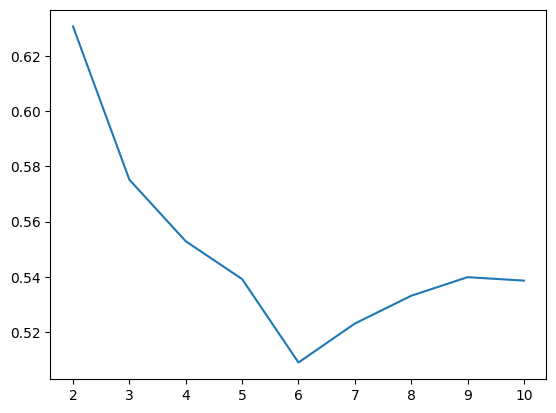

In [45]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

scores = []
for n in range(2, 11, 1):
    km = KMeans( n_clusters=n, random_state = 808, n_init = 10)
    km.fit(X)
    labels_ = km.predict(X)
    scores.append(silhouette_score(X,labels_ ))

plt.plot(range(2, 11, 1), scores)